<a href="https://colab.research.google.com/github/nicohervas/Procesos-Estocasticos/blob/main/Simulacion_MCs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# COMPLETAR (usa dos bucles for, uno sobre n_samples y otro sobre n_steps).

def simular_trayectorias(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.
  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.
  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  # Paso 0: por comodidad, podemos crear una variable que guarde el valor de m (el número de estados)
  m = P.shape[0]
  # Paso 1: crear un array de shape (n_samples, n_steps) con valores arbitrarios. Este array será el que devolvamos, una vez relleno.
  trayectorias = np.zeros((n_samples, n_steps))

  # Paso 2: simula el estado inicial para cada una de las n_samples trayectorias y guárdalo en la primera columna del array trayectorias.
  # Mira la función np.random.choice, que permite simular justo lo que buscamos a través de sus variados argumentos.
  trayectorias[:,0] = np.random.choice(m, size=n_samples, p=pi_sup_1)

  # Paso 3: iterando sobre n_samples y n_steps, rellena todo el array "trayectorias". Puedes usar de nuevo np.random.choice
  for step in range(1, n_steps):
    for sample in range(n_samples):
      trayectorias[sample, step] = np.random.choice(m, p=P[int(trayectorias[sample, step-1])])

  return trayectorias

In [3]:
%%timeit
# Celda para la versión menos eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias(P, pi_sup_1, n_samples, n_steps)

1.9 s ± 679 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [4]:
# COMPLETAR: usando solo un bucle for, sobre n_steps

def simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC.
  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_samples: número de trayectorias a simular. Int.
  n_steps: número de pasos de la simulación. Int.
  Output:
  trayectorias: trayectorias simuladas. Numpy array con shape (n_samples, n_steps).
  """

  # Paso 0: por comodidad, podemos crear una variable que guarde el valor de m (el número de estados)
  m = P.shape[0]

  # Paso 1: crear un array de shape (n_samples, n_steps) con valores arbitrarios. Este array será el que devolvamos, una vez relleno.
  trayectorias = np.zeros((n_samples, n_steps))

  # Paso 2: simula el estado inicial para cada una de las n_samples trayectorias y guárdalo en la primera columna del array trayectorias.
  # Mira la función np.random.choice, que permite hacer justo esto a través de sus variados argumentos.
  trayectorias[:,0] = np.random.choice(m, size=n_samples, p=pi_sup_1)

  # Paso 3: iterando sobre n_steps, utiliza numpy (en vez de for) para generar conjuntamente todas las trayectorias.
  # Recuerda (o piensa o busca) cómo funciona np.random.choice a partir de la generación de un número aleatorio que sigue una uniforme en el intervalo (0,1).
  # Implementa ese proceso manualmente con arrays de numpy. En particular puedes mirar np.argmax(), que puede usarse para proporcionar el primer índice que cumple cierta condición.
  for step in range(1, n_steps):
    estado_actual = trayectorias[:, step-1].astype(int)
    filas_P = P[estado_actual]
    cdf = np.cumsum(filas_P, axis=1)
    u = np.random.uniform(0, 1, size=(n_samples, 1))
    trayectorias[:, step] = np.argmax(cdf > u, axis=1)

  return trayectorias

In [5]:
%%timeit
# Celda para la versión más eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

5.64 ms ± 370 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


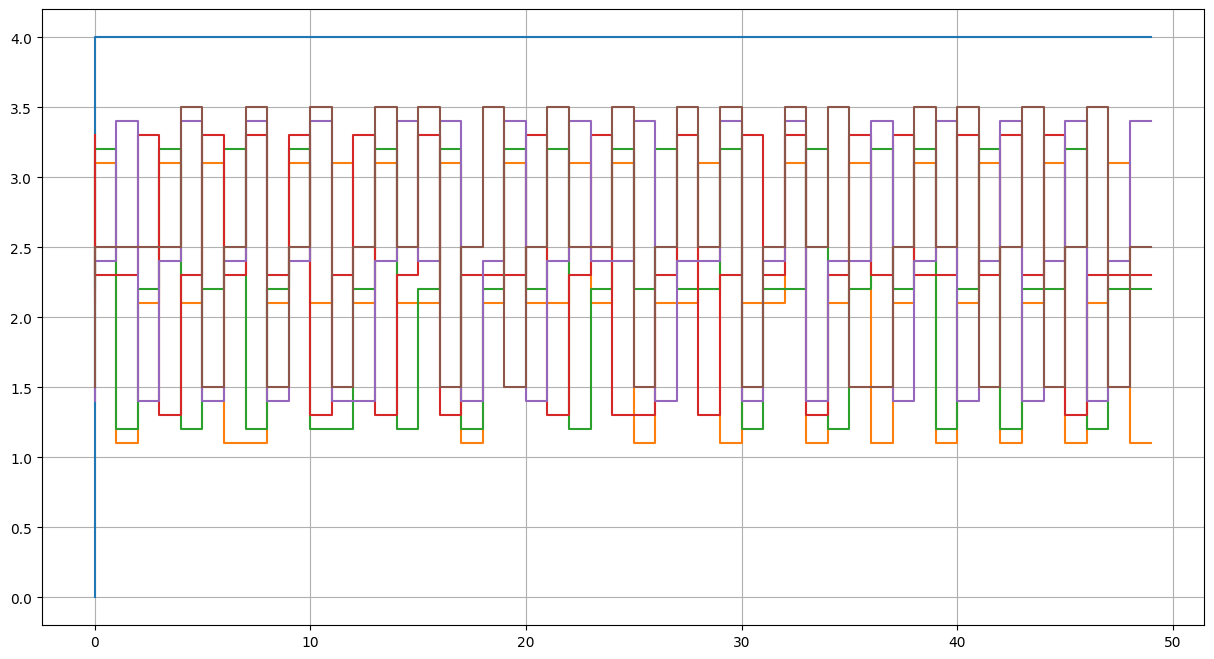

In [33]:
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 6
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)
x = np.arange(n_steps)
a = (np.arange(n_samples) * 0.1).reshape(n_samples, 1)
trayectorias = trayectorias + a
plt.figure(figsize=(15, 8))
plt.step(x, trayectorias.T)
plt.grid()
plt.show()


In [7]:
def obtener_marginal(P, pi_sup_1, n):
  """
  Función para calcular la distribución marginal de una MC en cierto instante.
  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n: instante de tiempo en el que se quiere calcular la distribución marginal. Int.
  Output:
  marginal: distribución marginal en el instante n (es decir, lo que hemos llamado pi^{(n)}). Numpy array con shape (m,).
  """
  # Paso único: recuerda cómo se calcula la marginal en el instante n en base al producto matricial.
  # El producto matricial entre dos arrays de numpy A y B se denota con @, es decir, A @ B
  # También puedes buscar cómo calcular la k-ésima potencia de una matriz: A^k (mira np.linalg.matrix_power)
  marginal = pi_sup_1 @ np.linalg.matrix_power(P, n-1)
  return marginal

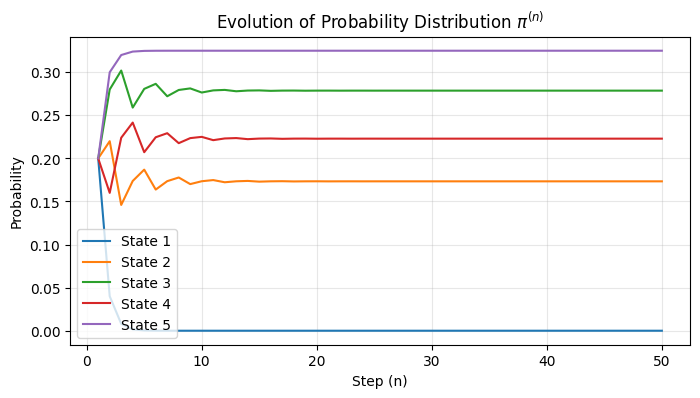

In [8]:
# Completar para diapositiva 61

P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.ones(5) * 0.2

# Completar usando la función anterior "obtener_marginal" y plt.plot
n_pasos = 50
m = P.shape[0]

marginales = np.zeros((m, n_pasos))
for i in range(n_pasos):
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i+1)

plt.figure(figsize=(8, 4))
for j in range(m):
    plt.plot(np.arange(1, n_steps+1), marginales[j,:], label=f"State {j+1}")
plt.xlabel("Step (n)")
plt.ylabel("Probability")
plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

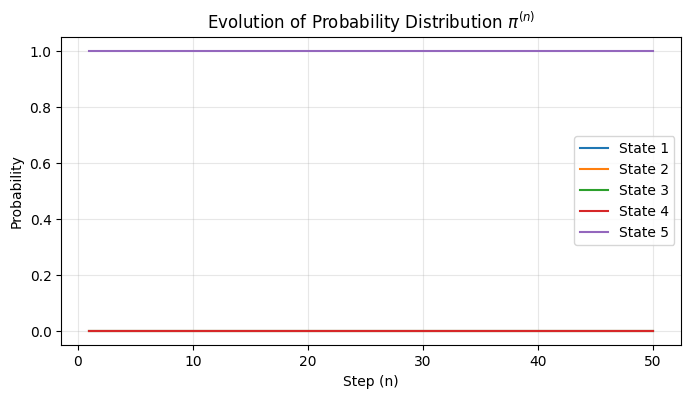

In [9]:
# Completar para diapositiva 63

P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = [0, 0, 0, 0, 1]

# Completar usando la función anterior "obtener_marginal" y plt.plot
n_pasos = 50
m = P.shape[0]

marginales = np.zeros((m, n_pasos))
for i in range(n_pasos):
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i+1)

plt.figure(figsize=(8, 4))
for j in range(m):
    plt.plot(np.arange(1, n_steps+1), marginales[j,:], label=f"State {j+1}")
plt.xlabel("Step (n)")
plt.ylabel("Probability")
plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Vemos que al cambiar la el vector inicial también cambia a donde converge la distribución.

In [10]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):

  # Use DiGraph (Directed Graph)
  G = nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j] > 0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  # Define layout
  pos = nx.circular_layout(G)

  # Create the plot
  plt.figure(figsize=(8, 6))

  # Draw nodes and edges
  # 'connectionstyle' curves the edges to prevent overlap on bidirectional paths
  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  # 2. Add the weights as labels
  edge_labels = nx.get_edge_attributes(G, 'weight')

  # Optional: Format labels to look cleaner (e.g., 0.5 instead of 0.500000)
  formatted_edge_labels = {k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("State Transition Diagram with Weights")
  plt.show()

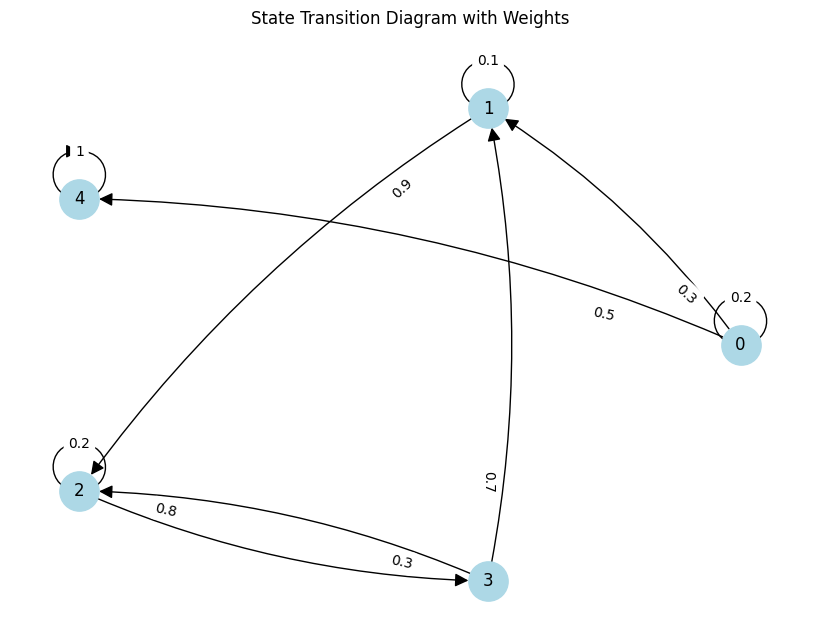

In [11]:
# COMPLETAR.

P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

states = np.arange(5)
dibujar_diagrama_transicion(P, states)

In [12]:
def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):
  """
  Función para visualizar la evolución de la distribución marginal para una MC.
  Input:
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  n_steps: instante de tiempo hasta el que se quiere visualizar. Int.
  Output:
  La función no devuelve nada por "return", simplemente realiza un gráfico.
  """
  # Paso 1: crear un array con shape (m, n_steps) y rellenarlo con las marginales en cada paso.
  # A diferencia de lo que se proponía en la sección 3, no uses la función "obtener_marginal" que habíamos definido.
  # Simplemente ve obteniendo las marginales una a una a partir de la anterior multiplicando por P.
  m = P.shape[0]
  marginales = np.zeros((m, n_steps))
  marginales[:,0] = pi_sup_1
  for i in range(1, n_steps):
    marginales[:,i] = marginales[:,i-1] @ P

  # Paso 2: Dibujar la trayectoria de cada componente de la marginal. Esto puede ser análogo a lo que se hizo al reproducir las diapositivas 61 y 63
  plt.figure(figsize=(8, 4))
  for j in range(m):
    plt.plot(np.arange(1, n_steps+1), marginales[j,:], label=f"State {j+1}")
  plt.xlabel("Step (n)")
  plt.ylabel("Probability")
  plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()

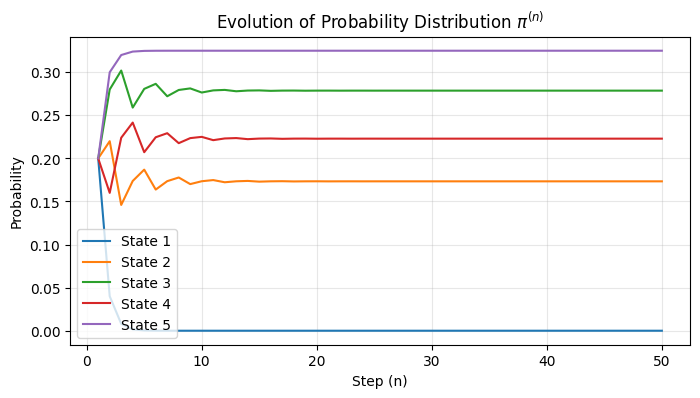

In [13]:
  P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
  ])
  pi_sup_1 = np.ones(5) * 0.2
  n_steps = 50
  visualizar_evolucion_marginal(P, pi_sup_1, n_steps)

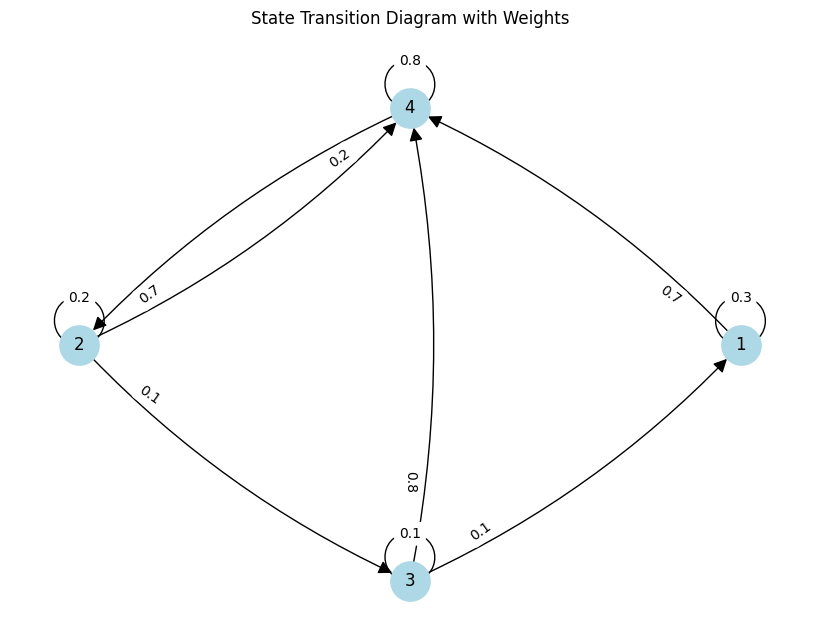

In [14]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

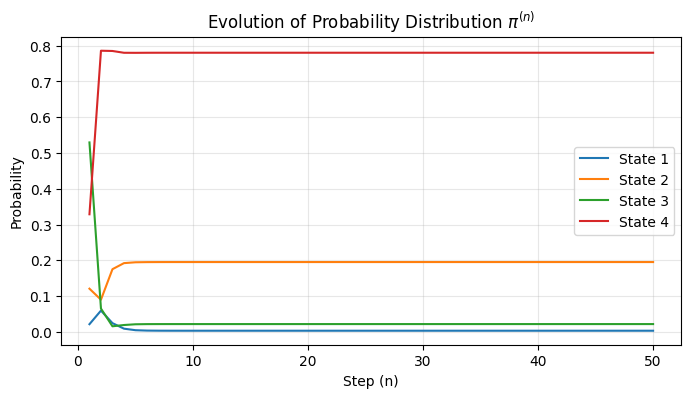

[0.00309598 0.19504644 0.02167183 0.78018576]


In [15]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Réllena las dos siguientes líneas para generar un pi_sup_1 aleatorio válido. Una idea es generar cada componente de una U(0,1) y luego normalizar para que las componentes sumen 1.
pi_sup_1 = np.random.uniform(0, 1, size=4)
pi_sup_1 = pi_sup_1 / pi_sup_1.sum()

visualizar_evolucion_marginal(P, pi_sup_1, 50)
print( obtener_marginal(P, pi_sup_1, 50) )

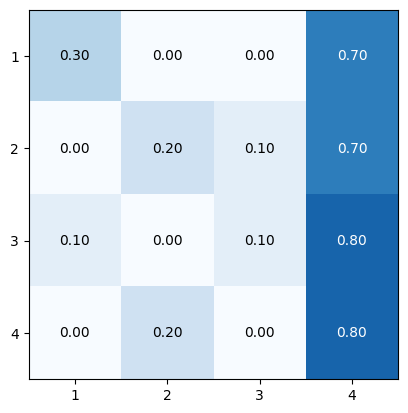

In [16]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Dibujar el heatmap
plt.imshow(P, cmap='Blues', vmin=0, vmax=1)

# Añadir texto con los valores explícitos
m = P.shape[0]
for i in range(m):       # rows
        for j in range(m):   # columns
            value = P[i, j]
            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"
            # Add text (note: text coordinates are (column, row) -> (j, i))
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))

plt.show()

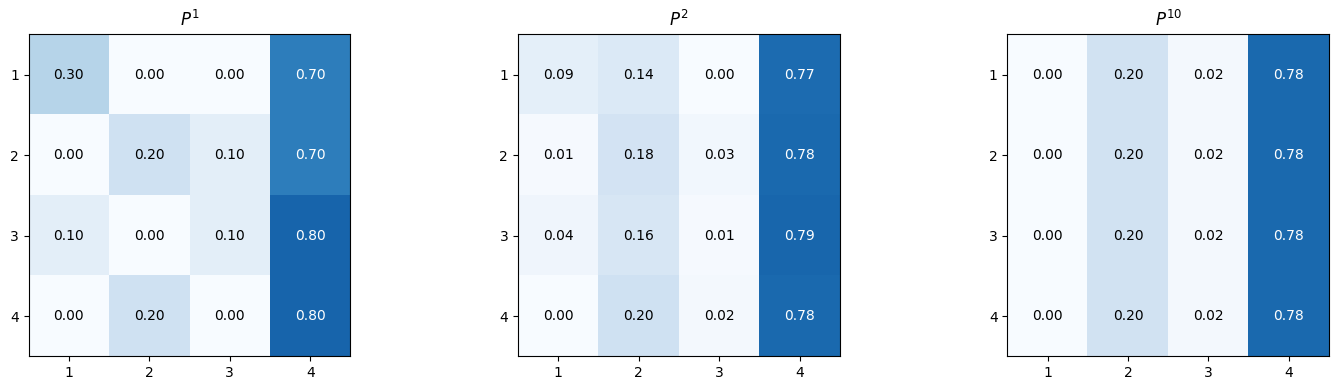

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps_to_show = [1, 2, 10]

for ax, n in zip(axes, steps_to_show):

    Pn = np.linalg.matrix_power(P, n)

    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"$P^{{{n}}}$")
    ax.set_xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    ax.set_yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    # Loop over data dimensions and create text annotations
    for i in range(Pn.shape[0]):       # rows
        for j in range(Pn.shape[1]):   # columns
            value = Pn[i, j]

            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"

            # Add text (note: text coordinates are (column, row) -> (j, i))
            ax.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

Vemos que la estructura de la matriz obliga a estar alternando entre dos grupos de estados, por lo que se comprueba que es periódica con periodo 2.

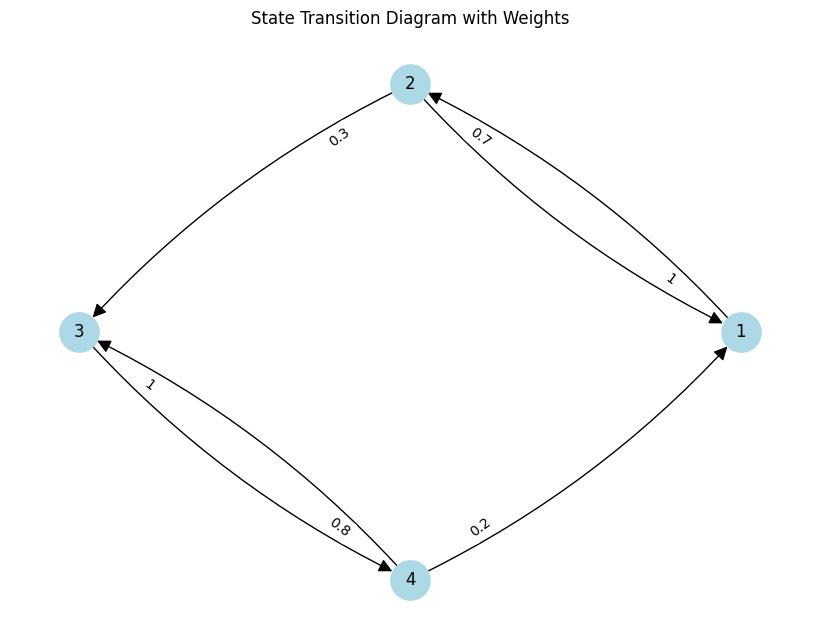

In [18]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

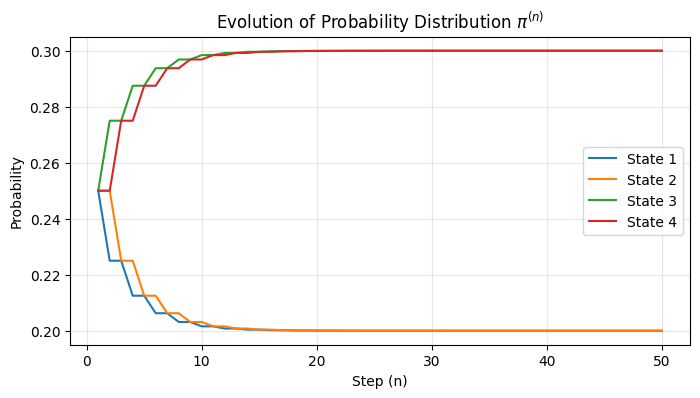

[0.2 0.2 0.3 0.3]


In [19]:
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

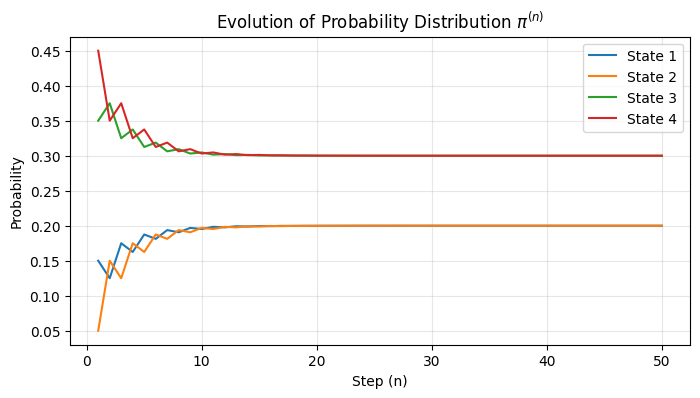

[0.2 0.2 0.3 0.3]


In [20]:
pi_sup_1 = np.array([0.15, 0.05, 0.35, 0.45])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

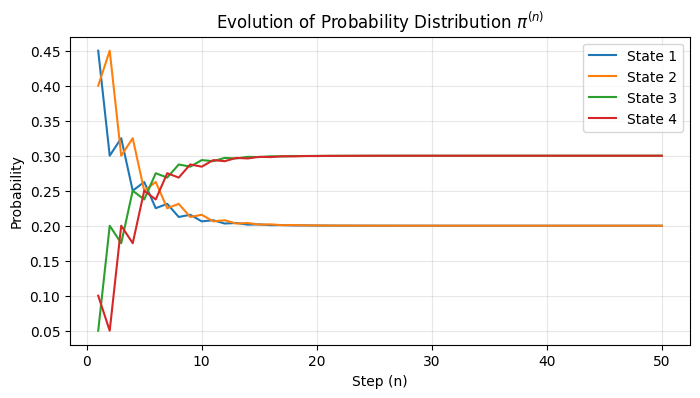

[0.20000001 0.20000001 0.29999999 0.29999999]


In [21]:
pi_sup_1 = np.array([0.45, 0.40, 0.05, 0.10])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

No contradice, porque la diapositiva 96 dice que la marginal converge para cualquier distribución inicial si y solo si la cadena es aperiódica. Y lo que se observa en las simulaciones es que hay distribuciones iniciales concretas para las que sí converge (las tres del ejemplo), pero hay otras para las que no converge como la de la siguiente celda.

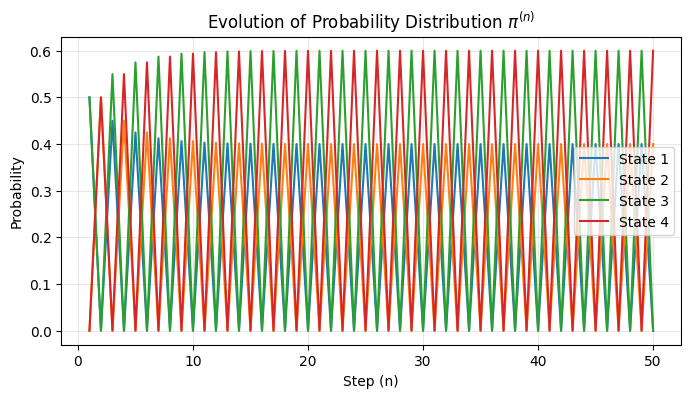

[0.         0.40000001 0.         0.59999999]


In [22]:

pi_sup_1 = np.array([0.5, 0.0, 0.5, 0.0])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

In [23]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):
  """
  Función que obtiene las proporciones empíricas de cada uno de los estados y en cada uno de los pasos, cuando simulamos una cantidad dada de trayectorias.
  Input:
  n_samples: número de trayectorias a simular. Int.
  n_steps: paso hasta el que se quieren calcular las proporciones. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  Output:
  props: Proporciones empíricas, es decir, p_i(n_samples, n) para i=1,...,m y n=1,...,n_steps. Array de shape (m, n_steps).
  """

  # Paso 1: utilizar la función "simular_trayectorias_effic" para simular n_samples trayectorias durante n_steps pasos.
  trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

  # Paso 2: compara cada item del array anterior con cada uno de los estados i=1,...,m.
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_samples, n_steps) que en cada posición (i,j,k) contenga True/False según si el ítem (j,k) del array "trayectorias" es igual a "i" (True) o no lo es (False).
  # Para hacer eso eficientemente, usa el broadcasting de numpy.
  estados = np.arange(m).reshape(m, 1, 1)
  is_equal_bool = (trayectorias == estados)

  # Paso 3: fíjate que las proporciones a devolver (props) no son más que hacer la media en la dimensión de "n_samples" en el array anterior (suponiendo que cada True cuenta como +1 y cada False cuenta como +0).
  # Utiliza np.mean() y su argumento "axis=..." para obtener el "props" buscado.
  props = np.mean(is_equal_bool, axis=1)

  return props

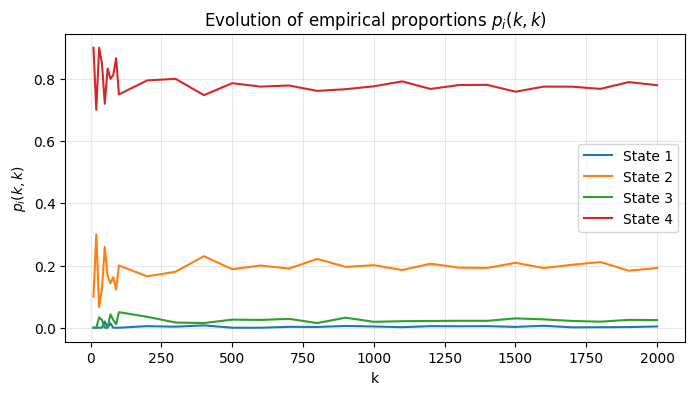

[0.004  0.192  0.0245 0.7795]
[0.00309598 0.19504644 0.02167183 0.78018576]


In [24]:
# Definimos la MC (nada que completar aquí)
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
m = P.shape[0]

# Definimos el "grid" de valores k que vamos a recorrer: 10, 20, 30, ... 100, 200, 300, ..., 2000 (nada que completar aquí)
grid = np.concatenate( (np.arange(10, 101, 10),
                        np.arange(200, 2001, 100)) )

# Obtenemos p_i(k,k) para i=1,...,m y para k en el grid anterior.
# Guardamos los resultados en un array "props_plot" de shape (m, len(grid)). (Nótese que len(grid) no es más que la longitud del grid).
props_plot = np.zeros((m, len(grid)))   # (m, len(grid))
for j in range(len(grid)):
  props_plot[:,j] = proporciones_empiricas_hasta_cierto_paso(grid[j], grid[j], P, pi_sup_1)[:,-1]

# A continuación se hace el gráfico. (nada que completar aquí)
plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(grid, props_plot[i,:], label=f"State {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolution of empirical proportions $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostramos por pantalla dos cosas:
# Primero, las proporciones para el último valor de k, es decir, p_i(2000,2000).
# Segundo, la distribución estacionaria de la MC.
# Según vimos en clase, lo primero debería parecerse a lo segundo para k grande. Y efectivamente vemos que es así.
# No obstante, dependiendo de la ejecución concreta, se parecerá más o menos (una cuestión interesante sería estudiar la velocidad de convergencia, que no parece ser muy elevada porque, para k=2000, aún no parece estabilizarse del todo)
print(props_plot[:,-1])
print(obtener_marginal(P, pi_sup_1, 50) )

In [25]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):
  """
  Función que calcula la frecuencia empírica de visitas a cada uno de los estados para una trayectoria de una MC hasta cierto paso.
  Input:
  n_steps: paso hasta el que queremos calcular las frecuencias. Se calcularán las frecuencias para n pasos, con n=1,2,..., n_steps. Int.
  P: matriz de transición de la MC. Numpy array con shape (m, m), donde m es el número de estados.
  pi_sup_1: distribución inicial de la MC. Numpy array con shape (m,).
  Output:
  frecuencias_hasta_cierto_paso: frecuencias empíricas obtenidas, es decir el valor q_i(n) para i=1,...,m y n=1,...,n_steps. Array con shape (m, n_steps)
  """

  # Paso 1: simular 1 trayectoria para la MC, hasta el paso n_steps
  trayectoria = simular_trayectorias_effic(P, pi_sup_1, 1, n_steps)  # (1, n_steps)

  # Paso 2: compara cada valor obtenido con cada uno de los m posibles estados.
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_steps) que en la posición (i,j) contenga True/False: True si en el paso j la trayectoria ha visitado justo el estado i, y False en otro caso.
  # Para ello, no uses ningún bucle for, usa simplemente el broadcasting de numpy.
  m = P.shape[0]
  estados = np.arange(m).reshape(m, 1)
  is_equal_bool = (trayectoria == estados)  # (m, n_steps)

  # Paso 3: A partir del array "is_equal_bool", piensa cómo obtener un array "recuentos_hasta_cierto_paso" que tenga la misma shape (m, n_steps), y que en el elemento (i,j) contenga
  # la cantidad de veces que se ha visitado el estado i-ésimo hasta el paso j-ésimo. Puedes mirar la función np.cumsum y tener en cuenta que, a la hora de hacer operaciones algebraicas,
  # los True cuentan como +1 mientras que los False cuentan como +0.
  recuentos_hasta_cierto_paso = np.cumsum(is_equal_bool, axis=1)  # (m, n_steps)

  # Paso 4: A partir del array "recuentos_hasta_cierto_paso", piensa cómo obtener el array "frecuencias_hasta_cierto_paso" que queremos devolver.
  # No uses bucles for, solo el broadcasting de numpy.
  frecuencias_hasta_cierto_paso = recuentos_hasta_cierto_paso / np.arange(1, n_steps+1)   # (m, n_steps)

  return frecuencias_hasta_cierto_paso    # (m, n_steps)

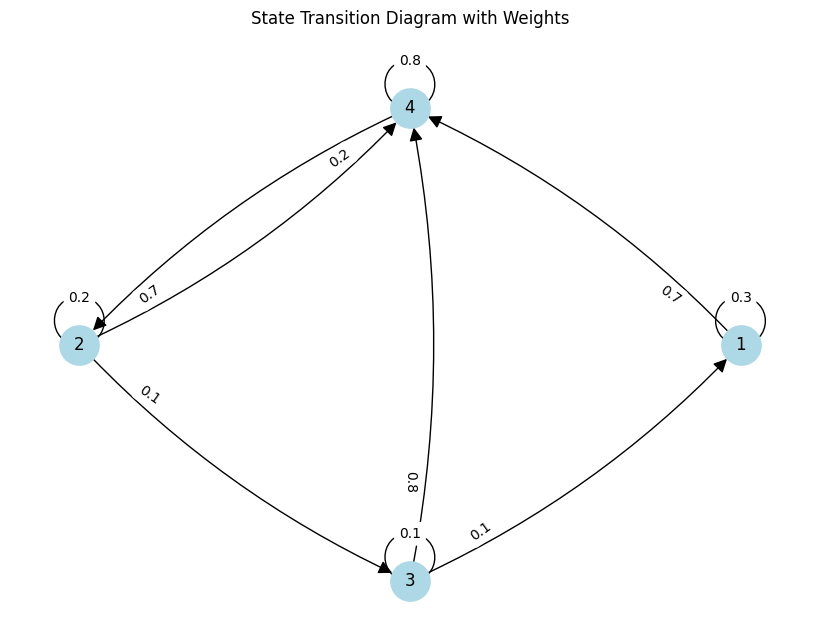

In [26]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

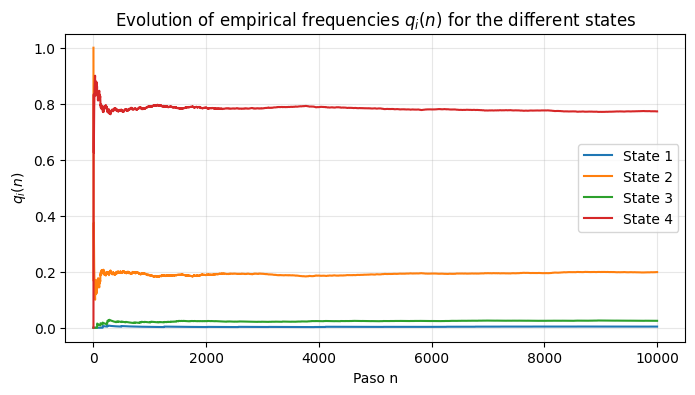

[0.004  0.1987 0.0247 0.7726]


In [27]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i,:] , label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

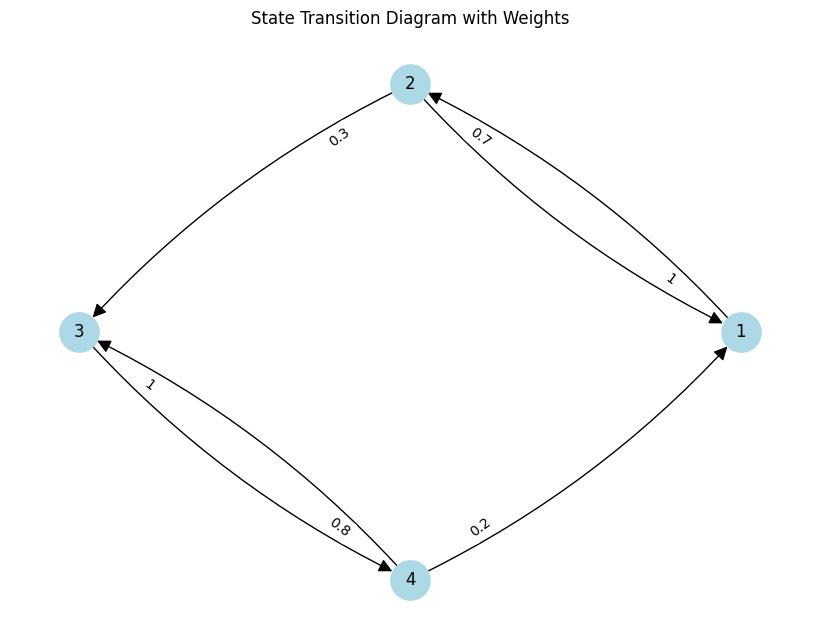

In [28]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

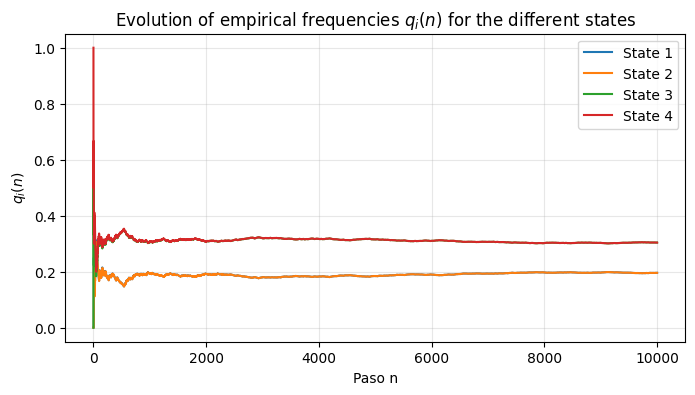

[0.196 0.196 0.304 0.304]


In [29]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
pi_sup_1 = np.array([0.2, 0.3, 0.2, 0.3])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i,:] , label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Efectivamente, aunque la distribución marginal no converge para esta distribución inicial (como vimos en la sección 4), las frecuencias empíricas sí convergen a la distribución estacionaria [0.2, 0.2, 0.3, 0.3]. Esto ilustra que el teorema ergódico es más general que el teorema de convergencia de MCs, ya que no requiere aperiodicidad, solo unicadinalidad.